# Notes
* Near 100% accuracy in the paper is achieved by data-driven threshold-based approach(Not ML-based).
* "_The grid chosen for the simulations and extraction of the results was the IEEE 13 node test feeder_". The data in the paper is generated via Simulink on benchmark grids (IEEE 13-node for fault classification, CIGRE European LV benchmark for fault detection)(Not real data) https://cmte.ieee.org/pes-testfeeders/resources/
* The real data used here has noise and sometimes ambiguous subcategories
* Fault detection CatBoost in paper gets 97.61% accuracy, fault classification(which is ~100%) is threshold-based as mentioned above.

# Idea for this project:
* Creating a "classification pipeline": CatBoost will be used first to classify between first 4 main categories since the accuracy of this is very high 96-something%.
* Then for each other subcategory train a separate model(to be honest RandomForest/CatBoost/ and XG-boost are pretty much the same. XGBoost was just slightly(0.01) better at least for my parameters).

In [3]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from catboost import CatBoostClassifier
import matplotlib.pyplot as plt

fields_to_drop = [
    'sample', 'file_name', 'ML_1', 'ML_1_1', 'ML_1_1_1', 'ML_1_2','ML_2','ML_2_1_1','ML_2_1_2','ML_2_1_3','ML_2_2','ML_2_3',
    'ML_2_3_1','ML_2_4_1','ML_2_4_2','ML_2_5_1','ML_2_6','ML_2_7_1','ML_2_7_2','ML_3','ML_3_1','ML_3_2','ML_3_3','ML_3_4',
    'ML_3_5', 'event_type']

### Training CatBoost for 4 categories

0:	learn: 0.8097947	test: 0.8105550	best: 0.8105550 (0)	total: 282ms	remaining: 4m 42s
20:	learn: 0.9136017	test: 0.9132463	best: 0.9132463 (20)	total: 6.05s	remaining: 4m 42s
40:	learn: 0.9194678	test: 0.9190733	best: 0.9190733 (40)	total: 11.8s	remaining: 4m 37s
60:	learn: 0.9260608	test: 0.9256587	best: 0.9256587 (60)	total: 17.4s	remaining: 4m 27s
80:	learn: 0.9323975	test: 0.9318745	best: 0.9318745 (80)	total: 22.9s	remaining: 4m 19s
100:	learn: 0.9372975	test: 0.9367449	best: 0.9367449 (100)	total: 28.9s	remaining: 4m 16s
120:	learn: 0.9407313	test: 0.9399309	best: 0.9399309 (120)	total: 34.2s	remaining: 4m 8s
140:	learn: 0.9432646	test: 0.9424691	best: 0.9424691 (140)	total: 39.5s	remaining: 4m
160:	learn: 0.9454255	test: 0.9445194	best: 0.9445194 (160)	total: 45.2s	remaining: 3m 55s
180:	learn: 0.9475349	test: 0.9467107	best: 0.9467107 (180)	total: 50.5s	remaining: 3m 48s
200:	learn: 0.9493375	test: 0.9485019	best: 0.9485019 (200)	total: 56.2s	remaining: 3m 43s
220:	learn: 0.95

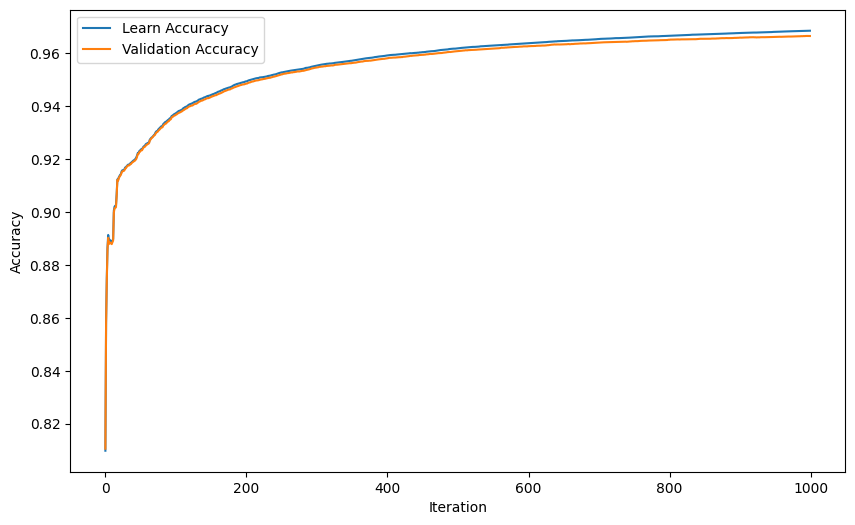

Best Train Accuracy: 0.9684667947164232
Score Test Accuracy: 0.9664936470552367


In [5]:
labeled_dataset = pd.read_csv('data/labeled_processed_4Categories.csv')

train, test = train_test_split(
    labeled_dataset,
    test_size=0.2,
    random_state=1,
    stratify=labeled_dataset['event_type']
)

train_features = train.drop(fields_to_drop, axis=1)
train_labels = train['event_type']

test_features = test.drop(fields_to_drop, axis=1)
test_labels = test['event_type']

classifier = CatBoostClassifier(
    iterations=1000,
    max_depth=7,
    random_seed=2,
    learning_rate=0.1,
    eval_metric="Accuracy",
    loss_function="MultiClass",
    early_stopping_rounds=20
)

classifier.fit(
    train_features, train_labels,
    eval_set=(test_features, test_labels),
    verbose=20,
    plot=False
)

plt.figure(figsize=(10, 6))
plt.plot(classifier.evals_result_['learn']['Accuracy'], label='Learn Accuracy')
plt.plot(classifier.evals_result_['validation']['Accuracy'], label='Validation Accuracy')
plt.xlabel('Iteration')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

print(f"Best Train Accuracy: {classifier.evals_result_['learn']['Accuracy'][-1]}")
test_score = classifier.score(test_features, test_labels)
print(f"Score Test Accuracy: {test_score}")

classifier.save_model("CatBoost_4Categories", format="cbm")

### Training CatBoost Subcategory

In [7]:
def train_subcategory_model(main_category):
    labeled_dataset = pd.read_csv(f'data/labeled_processed_only_{main_category}.csv')
    
    train, test = train_test_split(
        labeled_dataset,
        test_size=0.2,
        random_state=1,
        stratify=labeled_dataset['event_type']
    )
    
    train_features = train.drop(fields_to_drop, axis=1)
    train_labels = train['event_type']
    
    test_features = test.drop(fields_to_drop, axis=1)
    test_labels = test['event_type']
    
    classifier = CatBoostClassifier(
        iterations=1000,
        max_depth=7,
        random_seed=2,
        learning_rate=0.1,
        eval_metric="Accuracy",
        loss_function="MultiClass",
        early_stopping_rounds=20
    )
    
    classifier.fit(
        train_features, train_labels,
        eval_set=(test_features, test_labels),
        verbose=20,
        plot=False
    )
    
    plt.figure(figsize=(10, 6))
    plt.plot(classifier.evals_result_['learn']['Accuracy'], label='Learn Accuracy')
    plt.plot(classifier.evals_result_['validation']['Accuracy'], label='Validation Accuracy')
    plt.xlabel('Iteration')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()
    
    print(f"Best Train Accuracy: {classifier.evals_result_['learn']['Accuracy'][-1]}")
    test_score = classifier.score(test_features, test_labels)
    print(f"Score Test Accuracy: {test_score}")
    
    classifier.save_model(f"CatBoost_{main_category}", format="cbm")

0:	learn: 0.8697894	test: 0.8694769	best: 0.8694769 (0)	total: 173ms	remaining: 2m 52s
20:	learn: 0.9262885	test: 0.9266686	best: 0.9269354 (19)	total: 4s	remaining: 3m 6s
40:	learn: 0.9345860	test: 0.9350262	best: 0.9350986 (38)	total: 7.75s	remaining: 3m 1s
60:	learn: 0.9396832	test: 0.9400034	best: 0.9400034 (60)	total: 11.4s	remaining: 2m 55s
80:	learn: 0.9442336	test: 0.9446947	best: 0.9446947 (80)	total: 15.1s	remaining: 2m 51s
100:	learn: 0.9467526	test: 0.9471147	best: 0.9471147 (100)	total: 19s	remaining: 2m 49s
120:	learn: 0.9492260	test: 0.9494813	best: 0.9494813 (120)	total: 22.5s	remaining: 2m 43s
140:	learn: 0.9520252	test: 0.9522938	best: 0.9522938 (140)	total: 26.1s	remaining: 2m 39s
160:	learn: 0.9544147	test: 0.9544661	best: 0.9544661 (160)	total: 29.8s	remaining: 2m 35s
180:	learn: 0.9559153	test: 0.9559981	best: 0.9559981 (180)	total: 33.6s	remaining: 2m 32s
200:	learn: 0.9573873	test: 0.9574044	best: 0.9574044 (200)	total: 37.3s	remaining: 2m 28s
220:	learn: 0.9583

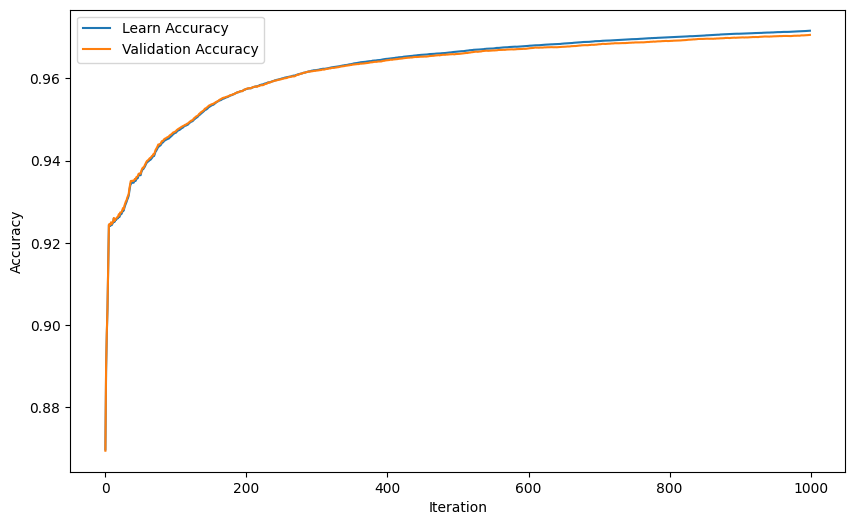

Best Train Accuracy: 0.9715384644700036
Score Test Accuracy: 0.9705256899823932


In [8]:
train_subcategory_model(0)
#train_subcategory_model(1)
#train_subcategory_model(2)
#train_subcategory_model(3)

# 5 Cats (Mixed Approach)

In [ ]:
AllCat = CatBoostClassifier()
AllCat.load_model("CatBoost_AllCategories") # trained to predict: 0(NoEvent), 1(OperationalSwitching), 2(AbnormalEvent), 3(FaultEvent)

NormalCat = CatBoostClassifier()
NormalCat.load_model("CatBoost_0NoEvent") # trained to predict: 0(NoEvent), 1(Some event happened)

OperationalCat = CatBoostClassifier()
OperationalCat.load_model("CatBoost_1OperationalSwitching") # trained to predict: 0(Some Event of other category) and OperationalSwitching subcategories: 1, 11, 111, 12

AbnormalCat = CatBoostClassifier()
AbnormalCat.load_model("CatBoost_2AbnormalEvents") # trained to predict: 0(Some Event of other category) and AbnormalEvents subcategories: 2, 211, 212, 213, 22, 23, 231, 241, 242, 251, 26, 271, 272

FaultCat = CatBoostClassifier()
FaultCat.load_model("CatBoost_3FaultEvents") # trained to predict: 0(Some Event of other category) and FaultEvents subcategories: 3, 31, 32, 33, 34, 35


def five_cats_predict(entry):
    all_cat_prediction = AllCat.predict(entry, prediction_type='Probability')
    category = get_category_with_highest_probability(all_cat_prediction)
    
    match category:
            
        case 1:
            operational_cat_prediction = OperationalCat.predict(entry, prediction_type='Probability')
            operational_cat_subcategory = get_category_with_highest_probability(operational_cat_prediction)
            if operational_cat_subcategory == 0:
                return go_through_every_cat(entry)
            return operational_cat_subcategory

        case 2:
            abnormal_cat_prediction = AbnormalCat.predict(entry, prediction_type='Probability')
            abnormal_cat_subcategory = get_category_with_highest_probability(abnormal_cat_prediction)
            if abnormal_cat_subcategory == 0:
                return go_through_every_cat(entry)
            return abnormal_cat_subcategory

        case 3:
            fault_cat_prediction = FaultCat.predict(entry, prediction_type='Probability')
            fault_cat_subcategory = get_category_with_highest_probability(fault_cat_prediction)
            if fault_cat_subcategory == 0:
                return go_through_every_cat(entry)
            return fault_cat_subcategory

        case _: #basically case 0
            normal_cat_prediction = NormalCat.predict(entry, prediction_type='Probability')
            normal_cat_subcategory = get_category_with_highest_probability(normal_cat_prediction)
            if normal_cat_subcategory != 0:
                return go_through_every_cat(entry)
            return normal_cat_subcategory


def go_through_every_cat(entry):
    
    normal_cat_prediction = NormalCat.predict(entry, prediction_type='Probability')
    normal_cat_prediction = normal_cat_prediction[1:-1] # remove category 1, since it's basically saying it's wrong category
    
    operational_cat_prediction = OperationalCat.predict(entry, prediction_type='Probability')
    operational_cat_prediction = operational_cat_prediction[1:] # remove category 0, since it's basically saying it's wrong category
    
    abnormal_cat_prediction = AbnormalCat.predict(entry, prediction_type='Probability')
    abnormal_cat_prediction = abnormal_cat_prediction[1:] # remove category 0, since it's basically saying it's wrong category
    
    fault_cat_prediction = FaultCat.predict(entry, prediction_type='Probability')
    fault_cat_prediction = fault_cat_prediction[1:] # remove category 0, since it's basically saying it's wrong category

    most_probable_category = from each those categories choose the one with the biggest probability
    return most_probable_category